<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/NBA_Play_by_Play_Data_Auditor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Play-by-Play Data Auditor

**Author:** Jared Ozarzak  
**Focus:** Basketball Operations, Data Validation, Stats Auditing, and Sports Analytics

This project simulates a live NBA play-by-play data feed and audits it for common data quality issues that could affect basketball operations, analytics, official stat review, and downstream reporting.

The goal is to show how Python can be used to automatically flag errors in large sports data feeds, including:

- Invalid scoring values
- Missing player or team attribution
- Player-team mismatches
- Duplicate event IDs
- Clock sequence errors
- Possession sequence issues
- Running score mismatches

Instead of only analyzing box score statistics, this project focuses on the operational side of sports data: making sure the data is clean before analysts, coaches, or front offices use it.

In [9]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

random.seed(42)
np.random.seed(42)

In [10]:
def print_header(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

In [11]:
teams = {
    "CLE": {
        "team_name": "Cleveland Cavaliers",
        "players": {
            1001: "Donovan Mitchell",
            1002: "Darius Garland",
            1003: "Evan Mobley",
            1004: "Jarrett Allen",
            1005: "Max Strus",
            1006: "Caris LeVert",
            1007: "Isaac Okoro",
            1008: "Georges Niang"
        }
    },
    "BOS": {
        "team_name": "Boston Celtics",
        "players": {
            2001: "Jayson Tatum",
            2002: "Jaylen Brown",
            2003: "Kristaps Porzingis",
            2004: "Jrue Holiday",
            2005: "Derrick White",
            2006: "Al Horford",
            2007: "Payton Pritchard",
            2008: "Sam Hauser"
        }
    }
}

player_to_team = {}

for team_abbr, team_data in teams.items():
    for player_id in team_data["players"]:
        player_to_team[player_id] = team_abbr

player_lookup = {}

for team_abbr, team_data in teams.items():
    for player_id, player_name in team_data["players"].items():
        player_lookup[player_id] = player_name

In [12]:
event_types = [
    "Made Field Goal",
    "Missed Field Goal",
    "Free Throw",
    "Rebound",
    "Turnover",
    "Foul",
    "Substitution",
    "Timeout",
    "Steal",
    "Block"
]

def seconds_to_clock(seconds_remaining):
    minutes = seconds_remaining // 60
    seconds = seconds_remaining % 60
    return f"{minutes}:{seconds:02d}"

def generate_mock_pbp(num_events_per_quarter=185):
    rows = []
    event_id = 1
    cle_score = 0
    bos_score = 0
    possession_team = random.choice(["CLE", "BOS"])

    for quarter in range(1, 5):
        seconds_remaining = 720

        for _ in range(num_events_per_quarter):
            seconds_remaining -= random.randint(1, 12)
            if seconds_remaining < 0:
                seconds_remaining = 0

            team = possession_team
            opponent = "BOS" if team == "CLE" else "CLE"

            event_type = random.choices(
                event_types,
                weights=[18, 20, 10, 18, 8, 10, 5, 3, 4, 4],
                k=1
            )[0]

            player_id = random.choice(list(teams[team]["players"].keys()))
            player_name = player_lookup[player_id]

            points_scored = 0

            if event_type == "Made Field Goal":
                points_scored = random.choices([2, 3], weights=[75, 25], k=1)[0]
                if team == "CLE":
                    cle_score += points_scored
                else:
                    bos_score += points_scored
                possession_team = opponent

            elif event_type == "Free Throw":
                points_scored = random.choices([0, 1], weights=[15, 85], k=1)[0]
                if team == "CLE":
                    cle_score += points_scored
                else:
                    bos_score += points_scored

            elif event_type == "Turnover":
                possession_team = opponent

            elif event_type == "Defensive Rebound":
                possession_team = team

            rows.append({
                "EVENT_ID": event_id,
                "GAME_ID": "CLE_BOS_2026_001",
                "QUARTER": quarter,
                "TIME_REMAINING": seconds_to_clock(seconds_remaining),
                "SECONDS_REMAINING": seconds_remaining,
                "TEAM": team,
                "PLAYER_ID": player_id,
                "PLAYER_NAME": player_name,
                "EVENT_TYPE": event_type,
                "POINTS_SCORED": points_scored,
                "CLE_SCORE": cle_score,
                "BOS_SCORE": bos_score,
                "POSSESSION_TEAM": possession_team
            })

            event_id += 1

    return pd.DataFrame(rows)

df = generate_mock_pbp()

print_header("MOCK NBA PLAY-BY-PLAY FEED GENERATED")
print(f"Total events generated: {len(df)}")
df.head(10)


MOCK NBA PLAY-BY-PLAY FEED GENERATED
Total events generated: 740


,EVENT_ID,GAME_ID,QUARTER,TIME_REMAINING,SECONDS_REMAINING,TEAM,PLAYER_ID,PLAYER_NAME,EVENT_TYPE,POINTS_SCORED,CLE_SCORE,BOS_SCORE,POSSESSION_TEAM
0,1,CLE_BOS_2026_001,1,11:59,719,CLE,1004,Jarrett Allen,Foul,0,0,0,CLE
1,2,CLE_BOS_2026_001,1,11:55,715,CLE,1002,Darius Garland,Made Field Goal,2,2,0,BOS
2,3,CLE_BOS_2026_001,1,11:46,706,BOS,2007,Payton Pritchard,Made Field Goal,2,2,2,CLE
3,4,CLE_BOS_2026_001,1,11:44,704,CLE,1001,Donovan Mitchell,Missed Field Goal,0,2,2,CLE
4,5,CLE_BOS_2026_001,1,11:35,695,CLE,1007,Isaac Okoro,Missed Field Goal,0,2,2,CLE
5,6,CLE_BOS_2026_001,1,11:31,691,CLE,1005,Max Strus,Free Throw,1,3,2,CLE
6,7,CLE_BOS_2026_001,1,11:30,690,CLE,1003,Evan Mobley,Foul,0,3,2,CLE
7,8,CLE_BOS_2026_001,1,11:18,678,CLE,1005,Max Strus,Free Throw,1,4,2,CLE
8,9,CLE_BOS_2026_001,1,11:12,672,CLE,1007,Isaac Okoro,Made Field Goal,2,6,2,BOS
9,10,CLE_BOS_2026_001,1,11:06,666,BOS,2001,Jayson Tatum,Rebound,0,6,2,BOS


In [13]:
df_audit = df.copy()

# Error 1: Free throw incorrectly worth 2 points
free_throw_idx = df_audit[df_audit["EVENT_TYPE"] == "Free Throw"].sample(3, random_state=1).index
df_audit.loc[free_throw_idx, "POINTS_SCORED"] = 2

# Error 2: Made field goal incorrectly worth 4 points
fg_idx = df_audit[df_audit["EVENT_TYPE"] == "Made Field Goal"].sample(3, random_state=2).index
df_audit.loc[fg_idx, "POINTS_SCORED"] = 4

# Error 3: Missing player ID on critical events
critical_idx = df_audit[df_audit["EVENT_TYPE"].isin(["Turnover", "Foul", "Made Field Goal"])].sample(5, random_state=3).index
df_audit.loc[critical_idx, "PLAYER_ID"] = np.nan
df_audit.loc[critical_idx, "PLAYER_NAME"] = np.nan

# Error 4: Player assigned to wrong team
mismatch_idx = df_audit.sample(5, random_state=4).index
for idx in mismatch_idx:
    current_team = df_audit.loc[idx, "TEAM"]
    wrong_team = "BOS" if current_team == "CLE" else "CLE"
    wrong_player = random.choice(list(teams[wrong_team]["players"].keys()))
    df_audit.loc[idx, "PLAYER_ID"] = wrong_player
    df_audit.loc[idx, "PLAYER_NAME"] = player_lookup[wrong_player]

# Error 5: Duplicate event IDs
duplicate_idx = df_audit.sample(4, random_state=5).index
df_audit.loc[duplicate_idx, "EVENT_ID"] = df_audit.loc[duplicate_idx[0], "EVENT_ID"]

# Error 6: Clock sequence issue within same quarter
clock_error_idx = df_audit[df_audit["QUARTER"] == 2].sample(2, random_state=6).index
df_audit.loc[clock_error_idx, "SECONDS_REMAINING"] = 721
df_audit.loc[clock_error_idx, "TIME_REMAINING"] = "12:01"

print_header("INTENTIONAL DATA ERRORS INJECTED")
print("The mock feed now includes realistic data quality issues for the auditor to detect.")
df_audit.head(10)


INTENTIONAL DATA ERRORS INJECTED
The mock feed now includes realistic data quality issues for the auditor to detect.


,EVENT_ID,GAME_ID,QUARTER,TIME_REMAINING,SECONDS_REMAINING,TEAM,PLAYER_ID,PLAYER_NAME,EVENT_TYPE,POINTS_SCORED,CLE_SCORE,BOS_SCORE,POSSESSION_TEAM
0,1,CLE_BOS_2026_001,1,11:59,719,CLE,1004.0,Jarrett Allen,Foul,0,0,0,CLE
1,2,CLE_BOS_2026_001,1,11:55,715,CLE,1002.0,Darius Garland,Made Field Goal,2,2,0,BOS
2,3,CLE_BOS_2026_001,1,11:46,706,BOS,2007.0,Payton Pritchard,Made Field Goal,2,2,2,CLE
3,4,CLE_BOS_2026_001,1,11:44,704,CLE,1001.0,Donovan Mitchell,Missed Field Goal,0,2,2,CLE
4,5,CLE_BOS_2026_001,1,11:35,695,CLE,1007.0,Isaac Okoro,Missed Field Goal,0,2,2,CLE
5,6,CLE_BOS_2026_001,1,11:31,691,CLE,1005.0,Max Strus,Free Throw,1,3,2,CLE
6,7,CLE_BOS_2026_001,1,11:30,690,CLE,1003.0,Evan Mobley,Foul,0,3,2,CLE
7,8,CLE_BOS_2026_001,1,11:18,678,CLE,1005.0,Max Strus,Free Throw,1,4,2,CLE
8,9,CLE_BOS_2026_001,1,11:12,672,CLE,1007.0,Isaac Okoro,Made Field Goal,2,6,2,BOS
9,10,CLE_BOS_2026_001,1,11:06,666,BOS,2001.0,Jayson Tatum,Rebound,0,6,2,BOS


In [14]:
print_header("DATASET OVERVIEW")

print(f"Rows: {df_audit.shape[0]}")
print(f"Columns: {df_audit.shape[1]}")

print("\nColumn names:")
print(df_audit.columns.tolist())

print("\nEvent type distribution:")
display(df_audit["EVENT_TYPE"].value_counts().reset_index().rename(columns={"index": "EVENT_TYPE", "EVENT_TYPE": "COUNT"}))

print("\nMissing values:")
display(df_audit.isnull().sum().reset_index().rename(columns={"index": "COLUMN", 0: "MISSING_VALUES"}))


DATASET OVERVIEW
Rows: 740
Columns: 13

Column names:
['EVENT_ID', 'GAME_ID', 'QUARTER', 'TIME_REMAINING', 'SECONDS_REMAINING', 'TEAM', 'PLAYER_ID', 'PLAYER_NAME', 'EVENT_TYPE', 'POINTS_SCORED', 'CLE_SCORE', 'BOS_SCORE', 'POSSESSION_TEAM']

Event type distribution:


,COUNT,count
0,Missed Field Goal,148
1,Made Field Goal,134
2,Rebound,124
3,Free Throw,86
4,Foul,73
5,Turnover,60
6,Block,35
7,Substitution,32
8,Steal,29
9,Timeout,19



Missing values:


,COLUMN,MISSING_VALUES
0,EVENT_ID,0
1,GAME_ID,0
2,QUARTER,0
3,TIME_REMAINING,0
4,SECONDS_REMAINING,0
5,TEAM,0
6,PLAYER_ID,5
7,PLAYER_NAME,5
8,EVENT_TYPE,0
9,POINTS_SCORED,0


In [15]:
audit_results = []

def log_error(event_id, quarter, time_remaining, error_type, severity, description):
    audit_results.append({
        "EVENT_ID": event_id,
        "QUARTER": quarter,
        "TIME_REMAINING": time_remaining,
        "ERROR_TYPE": error_type,
        "SEVERITY": severity,
        "DESCRIPTION": description
    })

In [16]:
def audit_scoring_values(dataframe):
    for _, row in dataframe.iterrows():
        event_type = row["EVENT_TYPE"]
        points = row["POINTS_SCORED"]

        if event_type == "Free Throw" and points not in [0, 1]:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Scoring Validation",
                "High",
                f"Free throw recorded as {points} points. Valid free throw values are 0 or 1."
            )

        if event_type == "Made Field Goal" and points not in [2, 3]:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Scoring Validation",
                "High",
                f"Made field goal recorded as {points} points. Valid made field goal values are 2 or 3."
            )

        if event_type not in ["Made Field Goal", "Free Throw"] and points != 0:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Scoring Validation",
                "Medium",
                f"{event_type} should not directly add points, but POINTS_SCORED was {points}."
            )

In [17]:
def audit_missing_attribution(dataframe):
    critical_events = [
        "Made Field Goal",
        "Missed Field Goal",
        "Free Throw",
        "Turnover",
        "Foul",
        "Steal",
        "Block"
    ]

    missing_rows = dataframe[
        dataframe["EVENT_TYPE"].isin(critical_events) &
        dataframe["PLAYER_ID"].isnull()
    ]

    for _, row in missing_rows.iterrows():
        log_error(
            row["EVENT_ID"],
            row["QUARTER"],
            row["TIME_REMAINING"],
            "Missing Attribution",
            "High",
            f"{row['EVENT_TYPE']} is missing a PLAYER_ID."
        )

In [18]:
def audit_player_team_mismatch(dataframe):
    for _, row in dataframe.dropna(subset=["PLAYER_ID"]).iterrows():
        player_id = int(row["PLAYER_ID"])
        listed_team = row["TEAM"]
        expected_team = player_to_team.get(player_id)

        if expected_team is not None and listed_team != expected_team:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Player-Team Mismatch",
                "High",
                f"Player {row['PLAYER_NAME']} belongs to {expected_team}, but event is listed under {listed_team}."
            )

In [19]:
def audit_duplicate_event_ids(dataframe):
    duplicate_rows = dataframe[dataframe["EVENT_ID"].duplicated(keep=False)]

    for _, row in duplicate_rows.iterrows():
        log_error(
            row["EVENT_ID"],
            row["QUARTER"],
            row["TIME_REMAINING"],
            "Duplicate Event ID",
            "Medium",
            f"EVENT_ID {row['EVENT_ID']} appears more than once in the feed."
        )

In [20]:
def audit_clock_sequence(dataframe):
    sorted_df = dataframe.sort_values(["QUARTER", "EVENT_ID"]).reset_index(drop=True)

    for quarter in sorted_df["QUARTER"].unique():
        q_df = sorted_df[sorted_df["QUARTER"] == quarter].reset_index(drop=True)

        for i in range(1, len(q_df)):
            previous_seconds = q_df.loc[i - 1, "SECONDS_REMAINING"]
            current_seconds = q_df.loc[i, "SECONDS_REMAINING"]

            if current_seconds > previous_seconds:
                log_error(
                    q_df.loc[i, "EVENT_ID"],
                    q_df.loc[i, "QUARTER"],
                    q_df.loc[i, "TIME_REMAINING"],
                    "Clock Sequence",
                    "Medium",
                    f"Game clock increased from {previous_seconds} to {current_seconds} seconds remaining."
                )

            if current_seconds > 720:
                log_error(
                    q_df.loc[i, "EVENT_ID"],
                    q_df.loc[i, "QUARTER"],
                    q_df.loc[i, "TIME_REMAINING"],
                    "Clock Sequence",
                    "High",
                    f"Clock shows {current_seconds} seconds remaining, which exceeds a 12-minute NBA quarter."
                )

In [21]:
def audit_possession_logic(dataframe):
    sorted_df = dataframe.sort_values(["QUARTER", "EVENT_ID"]).reset_index(drop=True)

    for i in range(1, len(sorted_df)):
        previous_event = sorted_df.loc[i - 1, "EVENT_TYPE"]
        current_event = sorted_df.loc[i, "EVENT_TYPE"]
        previous_team = sorted_df.loc[i - 1, "TEAM"]
        current_team = sorted_df.loc[i, "TEAM"]

        if previous_event == "Made Field Goal" and current_event == "Rebound":
            log_error(
                sorted_df.loc[i, "EVENT_ID"],
                sorted_df.loc[i, "QUARTER"],
                sorted_df.loc[i, "TIME_REMAINING"],
                "Possession Logic",
                "Medium",
                "Rebound was logged immediately after a made field goal."
            )

        if previous_event == "Turnover" and current_team == previous_team and current_event == "Made Field Goal":
            log_error(
                sorted_df.loc[i, "EVENT_ID"],
                sorted_df.loc[i, "QUARTER"],
                sorted_df.loc[i, "TIME_REMAINING"],
                "Possession Logic",
                "Medium",
                "Same team scored immediately after committing a turnover."
            )

In [22]:
def audit_running_score_consistency(dataframe):
    sorted_df = dataframe.sort_values(["QUARTER", "EVENT_ID"]).reset_index(drop=True)

    expected_cle = 0
    expected_bos = 0

    for _, row in sorted_df.iterrows():
        team = row["TEAM"]
        points = row["POINTS_SCORED"]

        if team == "CLE":
            expected_cle += points
        elif team == "BOS":
            expected_bos += points

        recorded_cle = row["CLE_SCORE"]
        recorded_bos = row["BOS_SCORE"]

        if recorded_cle != expected_cle:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Score Consistency",
                "High",
                f"CLE_SCORE is {recorded_cle}, but expected running score is {expected_cle}."
            )

        if recorded_bos != expected_bos:
            log_error(
                row["EVENT_ID"],
                row["QUARTER"],
                row["TIME_REMAINING"],
                "Score Consistency",
                "High",
                f"BOS_SCORE is {recorded_bos}, but expected running score is {expected_bos}."
            )

In [23]:
def run_full_audit(dataframe):
    global audit_results
    audit_results = []

    print_header("RUNNING NBA PLAY-BY-PLAY DATA AUDIT")

    audit_scoring_values(dataframe)
    audit_missing_attribution(dataframe)
    audit_player_team_mismatch(dataframe)
    audit_duplicate_event_ids(dataframe)
    audit_clock_sequence(dataframe)
    audit_possession_logic(dataframe)
    audit_running_score_consistency(dataframe)

    results_df = pd.DataFrame(audit_results)

    print(f"Events processed: {len(dataframe)}")
    print(f"Discrepancies flagged: {len(results_df)}")

    if len(results_df) == 0:
        print("STATUS: GREEN - No issues detected.")
    else:
        print("STATUS: RED - Manual review recommended.")

    return results_df

audit_df = run_full_audit(df_audit)
audit_df.head(20)


RUNNING NBA PLAY-BY-PLAY DATA AUDIT
Events processed: 740
Discrepancies flagged: 1016
STATUS: RED - Manual review recommended.


,EVENT_ID,QUARTER,TIME_REMAINING,ERROR_TYPE,SEVERITY,DESCRIPTION
0,248,2,4:57,Scoring Validation,High,Free throw recorded as 2 points. Valid free th...
1,263,2,3:03,Scoring Validation,High,Made field goal recorded as 4 points. Valid ma...
2,313,2,0:00,Scoring Validation,High,Made field goal recorded as 4 points. Valid ma...
3,337,2,0:00,Scoring Validation,High,Free throw recorded as 2 points. Valid free th...
4,393,3,9:36,Scoring Validation,High,Free throw recorded as 2 points. Valid free th...
5,627,4,5:06,Scoring Validation,High,Made field goal recorded as 4 points. Valid ma...
6,92,1,1:56,Missing Attribution,High,Foul is missing a PLAYER_ID.
7,183,1,0:00,Missing Attribution,High,Made Field Goal is missing a PLAYER_ID.
8,289,2,0:20,Missing Attribution,High,Foul is missing a PLAYER_ID.
9,448,3,4:21,Missing Attribution,High,Foul is missing a PLAYER_ID.


In [24]:
print_header("AUDIT SUMMARY BY ERROR TYPE")

error_type_summary = (
    audit_df
    .groupby("ERROR_TYPE")
    .size()
    .reset_index(name="ERROR_COUNT")
    .sort_values("ERROR_COUNT", ascending=False)
)

display(error_type_summary)


AUDIT SUMMARY BY ERROR TYPE


,ERROR_TYPE,ERROR_COUNT
5,Score Consistency,971
4,Possession Logic,18
0,Clock Sequence,7
6,Scoring Validation,6
2,Missing Attribution,5
3,Player-Team Mismatch,5
1,Duplicate Event ID,4


In [25]:
print_header("AUDIT SUMMARY BY SEVERITY")

severity_summary = (
    audit_df
    .groupby("SEVERITY")
    .size()
    .reset_index(name="ERROR_COUNT")
    .sort_values("ERROR_COUNT", ascending=False)
)

display(severity_summary)


AUDIT SUMMARY BY SEVERITY


,SEVERITY,ERROR_COUNT
0,High,989
1,Medium,27


In [26]:
print_header("AUDIT SUMMARY BY QUARTER")

quarter_summary = (
    audit_df
    .groupby("QUARTER")
    .size()
    .reset_index(name="ERROR_COUNT")
)

display(quarter_summary)


AUDIT SUMMARY BY QUARTER


,QUARTER,ERROR_COUNT
0,1,11
1,2,248
2,3,378
3,4,379


In [27]:
total_events = len(df_audit)
total_errors = len(audit_df)
error_rate = total_errors / total_events * 100

print_header("DATA QUALITY SCORECARD")

print(f"Total events processed: {total_events}")
print(f"Total discrepancies flagged: {total_errors}")
print(f"Overall error rate: {error_rate:.2f}%")

if error_rate < 1:
    print("Data Quality Grade: Excellent")
elif error_rate < 3:
    print("Data Quality Grade: Good")
elif error_rate < 7:
    print("Data Quality Grade: Needs Review")
else:
    print("Data Quality Grade: High Risk")


DATA QUALITY SCORECARD
Total events processed: 740
Total discrepancies flagged: 1016
Overall error rate: 137.30%
Data Quality Grade: High Risk


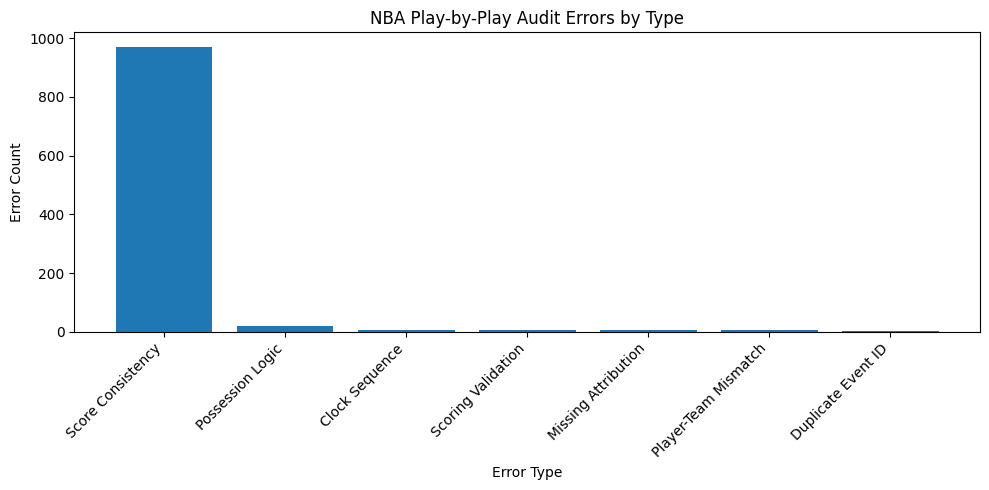

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(error_type_summary["ERROR_TYPE"], error_type_summary["ERROR_COUNT"])
plt.title("NBA Play-by-Play Audit Errors by Type")
plt.xlabel("Error Type")
plt.ylabel("Error Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

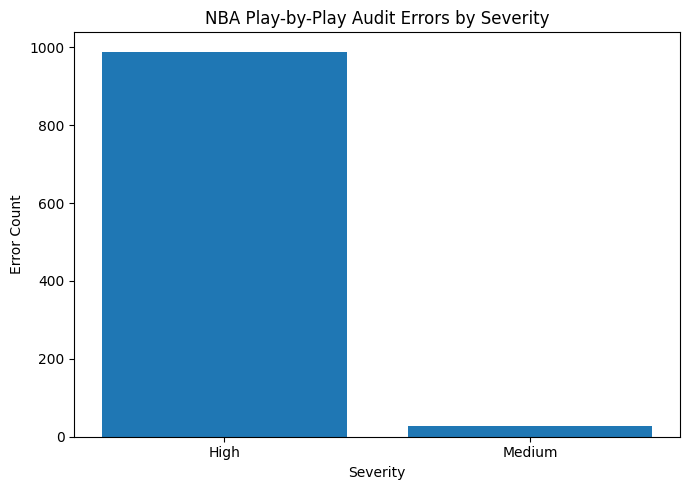

In [29]:
plt.figure(figsize=(7, 5))
plt.bar(severity_summary["SEVERITY"], severity_summary["ERROR_COUNT"])
plt.title("NBA Play-by-Play Audit Errors by Severity")
plt.xlabel("Severity")
plt.ylabel("Error Count")
plt.tight_layout()
plt.show()

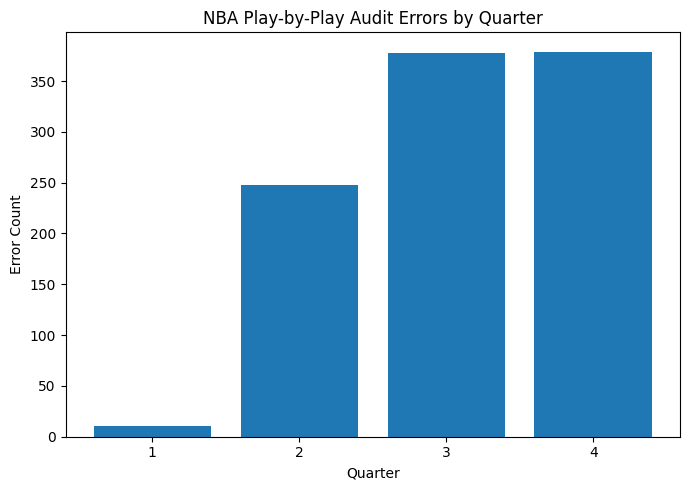

In [30]:
plt.figure(figsize=(7, 5))
plt.bar(quarter_summary["QUARTER"].astype(str), quarter_summary["ERROR_COUNT"])
plt.title("NBA Play-by-Play Audit Errors by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Error Count")
plt.tight_layout()
plt.show()

In [31]:
print_header("HIGH-SEVERITY ERRORS FOR MANUAL REVIEW")

high_severity_errors = audit_df[audit_df["SEVERITY"] == "High"].sort_values(
    ["QUARTER", "EVENT_ID"]
)

display(high_severity_errors.head(25))


HIGH-SEVERITY ERRORS FOR MANUAL REVIEW


,EVENT_ID,QUARTER,TIME_REMAINING,ERROR_TYPE,SEVERITY,DESCRIPTION
11,84,1,2:50,Player-Team Mismatch,High,"Player Al Horford belongs to BOS, but event is..."
6,92,1,1:56,Missing Attribution,High,Foul is missing a PLAYER_ID.
12,105,1,0:47,Player-Team Mismatch,High,"Player Caris LeVert belongs to CLE, but event ..."
7,183,1,0:00,Missing Attribution,High,Made Field Goal is missing a PLAYER_ID.
45,29,2,0:00,Score Consistency,High,"CLE_SCORE is 89, but expected running score is..."
46,29,2,0:00,Score Consistency,High,"BOS_SCORE is 82, but expected running score is..."
22,237,2,12:01,Clock Sequence,High,"Clock shows 721 seconds remaining, which excee..."
0,248,2,4:57,Scoring Validation,High,Free throw recorded as 2 points. Valid free th...
47,248,2,4:57,Score Consistency,High,"CLE_SCORE is 69, but expected running score is..."
48,249,2,4:54,Score Consistency,High,"CLE_SCORE is 69, but expected running score is..."


In [32]:
flagged_event_ids = audit_df["EVENT_ID"].unique()

df_flagged = df_audit.copy()
df_flagged["AUDIT_FLAG"] = df_flagged["EVENT_ID"].apply(
    lambda x: "FLAGGED" if x in flagged_event_ids else "CLEAR"
)

print_header("PLAY-BY-PLAY FEED WITH AUDIT FLAGS")
display(df_flagged.head(25))


PLAY-BY-PLAY FEED WITH AUDIT FLAGS


,EVENT_ID,GAME_ID,QUARTER,TIME_REMAINING,SECONDS_REMAINING,TEAM,PLAYER_ID,PLAYER_NAME,EVENT_TYPE,POINTS_SCORED,CLE_SCORE,BOS_SCORE,POSSESSION_TEAM,AUDIT_FLAG
0,1,CLE_BOS_2026_001,1,11:59,719,CLE,1004.0,Jarrett Allen,Foul,0,0,0,CLE,CLEAR
1,2,CLE_BOS_2026_001,1,11:55,715,CLE,1002.0,Darius Garland,Made Field Goal,2,2,0,BOS,CLEAR
2,3,CLE_BOS_2026_001,1,11:46,706,BOS,2007.0,Payton Pritchard,Made Field Goal,2,2,2,CLE,CLEAR
3,4,CLE_BOS_2026_001,1,11:44,704,CLE,1001.0,Donovan Mitchell,Missed Field Goal,0,2,2,CLE,CLEAR
4,5,CLE_BOS_2026_001,1,11:35,695,CLE,1007.0,Isaac Okoro,Missed Field Goal,0,2,2,CLE,CLEAR
5,6,CLE_BOS_2026_001,1,11:31,691,CLE,1005.0,Max Strus,Free Throw,1,3,2,CLE,CLEAR
6,7,CLE_BOS_2026_001,1,11:30,690,CLE,1003.0,Evan Mobley,Foul,0,3,2,CLE,CLEAR
7,8,CLE_BOS_2026_001,1,11:18,678,CLE,1005.0,Max Strus,Free Throw,1,4,2,CLE,CLEAR
8,9,CLE_BOS_2026_001,1,11:12,672,CLE,1007.0,Isaac Okoro,Made Field Goal,2,6,2,BOS,CLEAR
9,10,CLE_BOS_2026_001,1,11:06,666,BOS,2001.0,Jayson Tatum,Rebound,0,6,2,BOS,FLAGGED


In [33]:
def generate_nightly_report(dataframe, audit_dataframe):
    print_header("NIGHTLY NBA STATS AUDIT REPORT")

    print(f"Game ID: {dataframe['GAME_ID'].iloc[0]}")
    print(f"Matchup: Cleveland Cavaliers vs. Boston Celtics")
    print(f"Events Processed: {len(dataframe)}")
    print(f"Total Discrepancies: {len(audit_dataframe)}")
    print(f"Error Rate: {len(audit_dataframe) / len(dataframe) * 100:.2f}%")

    print("\nErrors by Type:")
    for _, row in error_type_summary.iterrows():
        print(f"- {row['ERROR_TYPE']}: {row['ERROR_COUNT']}")

    print("\nErrors by Severity:")
    for _, row in severity_summary.iterrows():
        print(f"- {row['SEVERITY']}: {row['ERROR_COUNT']}")

    print("\nTop Manual Review Items:")
    review_items = audit_dataframe.sort_values(["SEVERITY", "QUARTER", "EVENT_ID"]).head(10)

    for _, row in review_items.iterrows():
        print(
            f"[{row['SEVERITY']}] Q{row['QUARTER']} {row['TIME_REMAINING']} | "
            f"Event {row['EVENT_ID']} | {row['ERROR_TYPE']} | {row['DESCRIPTION']}"
        )

    print("\nFinal Status:")
    if len(audit_dataframe) == 0:
        print("GREEN - Feed verified.")
    elif len(audit_dataframe) / len(dataframe) < 0.03:
        print("YELLOW - Minor discrepancies found. Review recommended.")
    else:
        print("RED - High discrepancy volume. Manual review required.")

generate_nightly_report(df_audit, audit_df)


NIGHTLY NBA STATS AUDIT REPORT
Game ID: CLE_BOS_2026_001
Matchup: Cleveland Cavaliers vs. Boston Celtics
Events Processed: 740
Total Discrepancies: 1016
Error Rate: 137.30%

Errors by Type:
- Score Consistency: 971
- Possession Logic: 18
- Clock Sequence: 7
- Scoring Validation: 6
- Missing Attribution: 5
- Player-Team Mismatch: 5
- Duplicate Event ID: 4

Errors by Severity:
- High: 989
- Medium: 27

Top Manual Review Items:
[High] Q1 2:50 | Event 84 | Player-Team Mismatch | Player Al Horford belongs to BOS, but event is listed under CLE.
[High] Q1 1:56 | Event 92 | Missing Attribution | Foul is missing a PLAYER_ID.
[High] Q1 0:47 | Event 105 | Player-Team Mismatch | Player Caris LeVert belongs to CLE, but event is listed under BOS.
[High] Q1 0:00 | Event 183 | Missing Attribution | Made Field Goal is missing a PLAYER_ID.
[High] Q2 0:00 | Event 29 | Score Consistency | CLE_SCORE is 89, but expected running score is 50.
[High] Q2 0:00 | Event 29 | Score Consistency | BOS_SCORE is 82, b

In [36]:
df_audit.to_csv("mock_nba_play_by_play_feed.csv", index=False)
audit_df.to_csv("nba_play_by_play_audit_results.csv", index=False)
df_flagged.to_csv("nba_play_by_play_feed_with_audit_flags.csv", index=False)

print_header("EXPORT COMPLETE")
print("Files created:")
print("- mock_nba_play_by_play_feed.csv")
print("- nba_play_by_play_audit_results.csv")
print("- nba_play_by_play_feed_with_audit_flags.csv")


EXPORT COMPLETE
Files created:
- mock_nba_play_by_play_feed.csv
- nba_play_by_play_audit_results.csv
- nba_play_by_play_feed_with_audit_flags.csv


In [37]:
df_audit.to_csv("mock_nba_play_by_play_feed.csv", index=False)
audit_df.to_csv("nba_play_by_play_audit_results.csv", index=False)
df_flagged.to_csv("nba_play_by_play_feed_with_audit_flags.csv", index=False)

print_header("EXPORT COMPLETE")
print("Files created:")
print("- mock_nba_play_by_play_feed.csv")
print("- nba_play_by_play_audit_results.csv")
print("- nba_play_by_play_feed_with_audit_flags.csv")


EXPORT COMPLETE
Files created:
- mock_nba_play_by_play_feed.csv
- nba_play_by_play_audit_results.csv
- nba_play_by_play_feed_with_audit_flags.csv


# Portfolio Summary

This project demonstrates how Python can be used to support basketball operations and data quality workflows by auditing a simulated NBA play-by-play feed.

## What the auditor does

The tool reviews a large play-by-play dataset and automatically flags:

- Scoring errors
- Missing player attribution
- Player-team mismatches
- Duplicate event IDs
- Clock sequence problems
- Possession logic issues
- Running score inconsistencies

## Why this matters

Sports analytics depends on clean and reliable data. If play-by-play data contains errors, then lineup analysis, player evaluation, possession models, betting feeds, broadcast graphics, scouting reports, and internal dashboards can all be affected.

This project shows an operational analytics mindset: before using the data, validate it.

## Skills demonstrated

- Python
- pandas
- Data validation
- Sports analytics workflow design
- Basketball operations logic
- Automated reporting
- Error flagging and audit trails
- Data visualization
- CSV export for review workflows

## Potential real-world use cases

- NBA stats auditing
- Basketball operations data review
- Live game feed validation
- Broadcast/stat provider quality control
- Internal analytics database cleaning
- Automated discrepancy reports for manual review